<a href="https://colab.research.google.com/github/manaspathak2335-git/Hyperparameter-Tuning-Comparative-Study/blob/main/PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**I. Data Collection**

In [ ]:
#importing required libraries
from google.colab import drive
import pandas as pd

In [ ]:
#mounting the drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#reading complete dataset into pandas dataframe and displaying its info.
comp_data = pd.read_csv('/content/drive/MyDrive/Project_data/onlinefraud.csv')
print(comp_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None


In [ ]:
#printing shape of dataset
print(comp_data.shape)

(6362620, 11)


In [ ]:
#displaying top 5 rows of dataset
print(comp_data.head())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [ ]:
#statistical description of dataset
print(comp_data.describe())

               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    1.442584e+05   
max    7.430000e+02  9.244552e+07   5.958504e+07    4.958504e+07   

       oldbalanceDest  newbalanceDest       isFraud  isFlaggedFraud  
count    6.362620e+06    6.362620e+06  6.362620e+06    6.362620e+06  
mean     1.100702e+06    1.224996e+06  1.290820e-03    2.514687e-06  
std      3.399180e+06    3.674129e+06  3.590480e-02    1.585775e-03  
min      0.000000e+00    0.000000e+00  0.000000e+00    0.000000e+00  
25%      0.000000e+00    0.000000e+00

**II. Data Undersampling**

In [ ]:
#importing required libraries
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
#displaying class imbalance in data
print(comp_data['isFraud'].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64


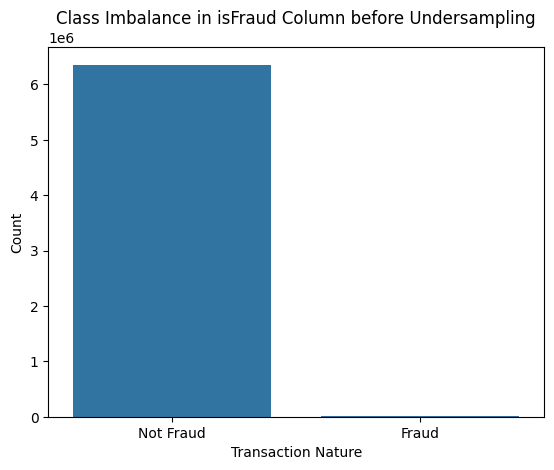

In [ ]:
#visualizing class imbalance in data
sns.countplot(x='isFraud', data=comp_data)
plt.title("Class Imbalance in isFraud Column before Undersampling")
plt.xlabel("Transaction Nature")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=['Not Fraud', 'Fraud'])
plt.show()

In [ ]:
#Random Under Sampling of majority class
x = comp_data.drop('isFraud', axis=1)
y = comp_data['isFraud']
rus = RandomUnderSampler(sampling_strategy = 1/9, random_state=42)
x_rus, y_rus = rus.fit_resample(x,y)
us_data = pd.concat([x_rus, y_rus], axis=1)
us_data.reset_index(drop=True, inplace=True)
print(us_data.shape)

(82130, 11)


In [ ]:
#class distribution after under sampling
print(us_data['isFraud'].value_counts())

isFraud
0    73917
1     8213
Name: count, dtype: int64


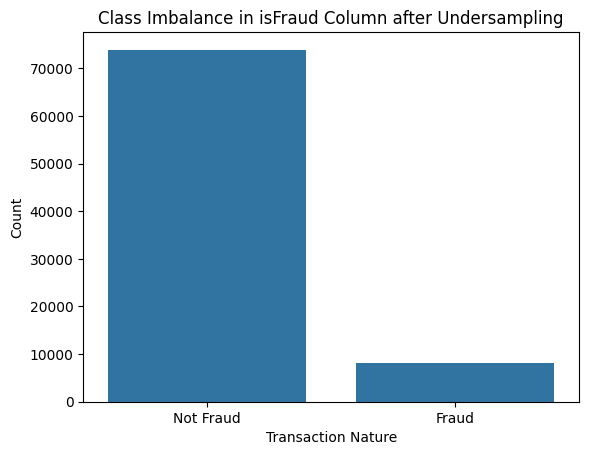

In [ ]:
#class distribution visualization after under sampling
sns.countplot(x='isFraud', data=us_data)
plt.title("Class Imbalance in isFraud Column after Undersampling")
plt.xlabel("Transaction Nature")
plt.ylabel("Count")
plt.xticks(ticks=[0,1], labels = ['Not Fraud','Fraud'])
plt.show()

In [ ]:
#saving undersampled data frame to google drive folder.
us_data.to_csv('/content/drive/MyDrive/Project_data/undersampled_onlinefraud.csv', index=False)

In [ ]:
#loading undersampled data from drive
us_data = pd.read_csv('/content/drive/MyDrive/Project_data/undersampled_onlinefraud.csv')

**III. Data Visualization**

<Axes: xlabel='type', ylabel='count'>

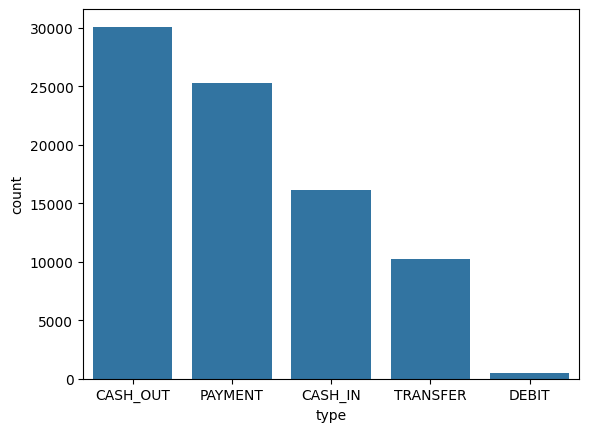

In [ ]:
#countplot of different transaction types
sns.countplot(x='type', data=us_data)

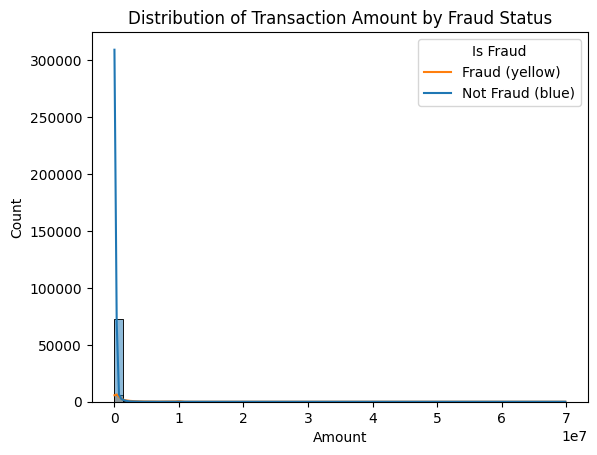

In [ ]:
#comparing non fraud vs fraud one
sns.histplot(data=us_data, x='amount', hue='isFraud', bins=50, kde=True)
##plt.xlim(0, 1000000)
plt.title('Distribution of Transaction Amount by Fraud Status')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.legend(title='Is Fraud', labels=['Fraud (yellow)', 'Not Fraud (blue)'])
plt.show()

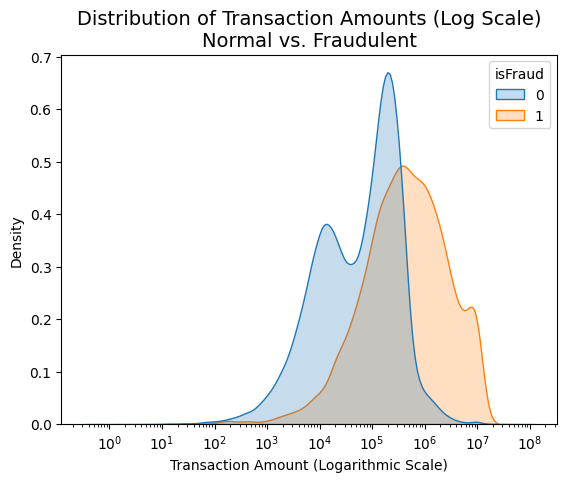

In [ ]:
#kde plot (amount vs probablity density(how much of transaction around x amount))
plot_data = us_data[us_data['amount']>0]
sns.kdeplot(data=plot_data, x='amount', hue='isFraud', fill=True, log_scale=True, common_norm=False)
plt.title("Distribution of Transaction Amounts (Log Scale)\nNormal vs. Fraudulent", fontsize=14)
plt.xlabel("Transaction Amount (Logarithmic Scale)")
plt.ylabel("Density")
plt.show()

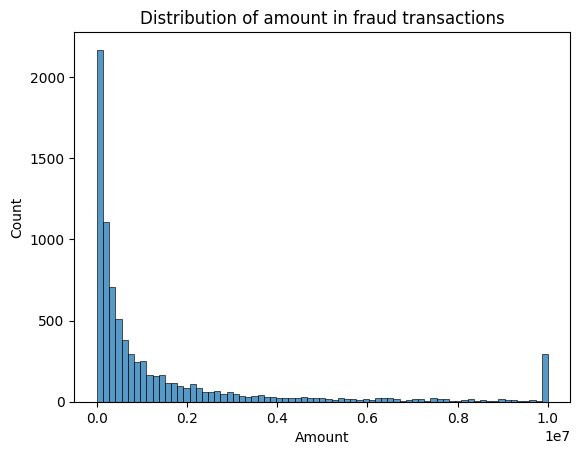

In [ ]:
#analysing where the most fraud transactions have occured!!
fraud_transactions = us_data[us_data['isFraud'] == 1]
sns.histplot(data=fraud_transactions, x ='amount')
plt.title('Distribution of amount in fraud transactions')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.show()

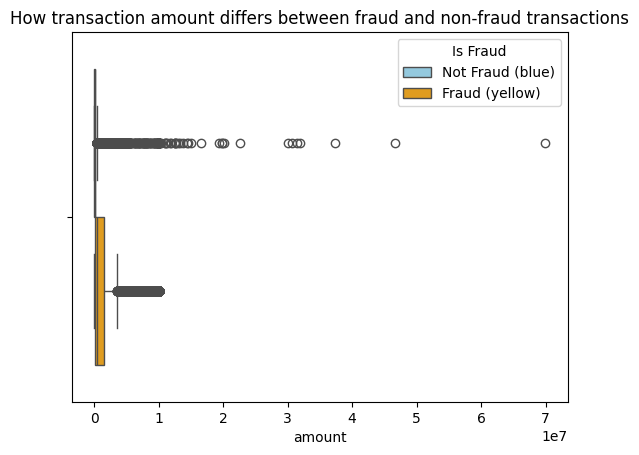

In [ ]:
#box plot(a statistical comparison)
sns.boxplot(x='amount', hue='isFraud', data=us_data, palette={0: 'skyblue', 1: 'orange'}, showfliers=True)
#0 : authentic transacrtions and 1 : fraud transactions
#plt.xlim(0, 16000000)
plt.title("How transaction amount differs between fraud and non-fraud transactions")
plt.legend(title='Is Fraud', labels=['Not Fraud (blue)', 'Fraud (yellow)'])
plt.show()

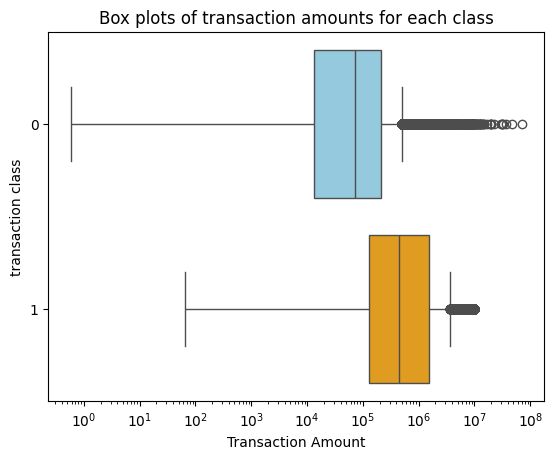

In [ ]:
#box plot(a statistical comparison)
plot_data = us_data[us_data['amount']>0]
sns.boxplot(x='amount', y='isFraud',hue='isFraud', data=plot_data,orient='h', palette=['skyblue','orange'], showfliers=True, legend=False)
plt.xscale('log')
plt.title("Box plots of transaction amounts for each class")
plt.xlabel("Transaction Amount")
plt.ylabel("transaction class")
plt.show()

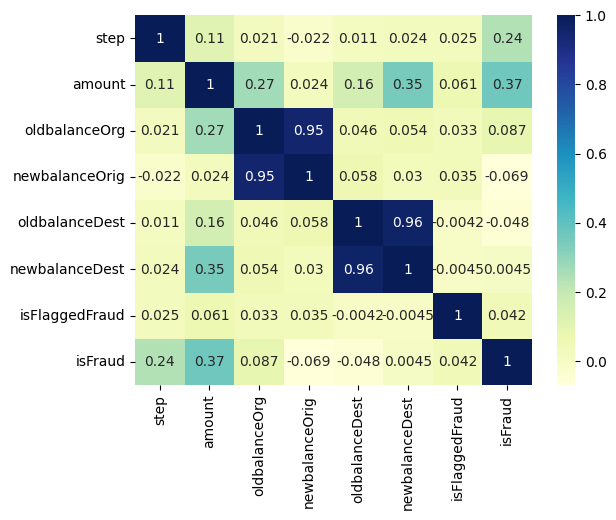

In [ ]:
#correlation heatmap (shows influence of feature on fraud cases)
co_mtrx = us_data.corr(numeric_only=True)
sns.heatmap(co_mtrx, cmap= "YlGnBu", annot = True)
plt.show()

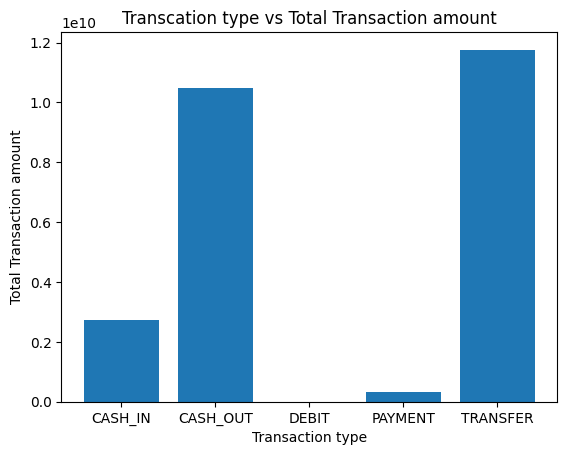

In [ ]:
#transaction amounts total volume for each transaction type
summed_data = us_data.groupby('type')['amount'].sum().reset_index()
plt.bar(x = 'type', height = 'amount', data= summed_data)
plt.title("Transcation type vs Total Transaction amount")
plt.xlabel("Transaction type")
plt.ylabel("Total Transaction amount")
plt.show()

**IV. Data Preprocessing**

In [ ]:
#importing required libraries
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [ ]:
#encoding 'type' column using OneHotEncoder
OH_encoder = OneHotEncoder(sparse_output=False)
type_col_arr = OH_encoder.fit_transform(us_data[['type']])
type_col_df = pd.DataFrame(type_col_arr, columns=OH_encoder.get_feature_names_out(['type']))
us_data.drop('type',axis=1,inplace=True)
us_data = pd.concat([us_data, type_col_df], axis=1)

In [ ]:
#defining new error columns to handle data leakage
us_data['errorBalanceOrig'] = us_data['newbalanceOrig'] + us_data['amount'] - us_data['oldbalanceOrg']
us_data['errorBalanceDest'] = us_data['oldbalanceDest'] + us_data['amount'] - us_data['newbalanceDest']

In [ ]:
#dropping irrelevent columns
data = us_data.drop(['nameOrig', 'nameDest','isFlaggedFraud','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest'], axis=1)

In [ ]:
#printing info() output of modified data
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82130 entries, 0 to 82129
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   step              82130 non-null  int64  
 1   amount            82130 non-null  float64
 2   isFraud           82130 non-null  int64  
 3   type_CASH_IN      82130 non-null  float64
 4   type_CASH_OUT     82130 non-null  float64
 5   type_DEBIT        82130 non-null  float64
 6   type_PAYMENT      82130 non-null  float64
 7   type_TRANSFER     82130 non-null  float64
 8   errorBalanceOrig  82130 non-null  float64
 9   errorBalanceDest  82130 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 6.3 MB
None
   step     amount  isFraud  type_CASH_IN  type_CASH_OUT  type_DEBIT  \
0   162  183806.32        0           0.0            1.0         0.0   
1   137     521.37        0           0.0            0.0         0.0   
2   179    3478.18        0           0.0            0.0

In [ ]:
#saving preprocessed data to google drive folder
data.to_csv('/content/drive/MyDrive/Project_data/preprocessed_onlinefraud.csv', index=False)

In [ ]:
#loading preprocessed data from drive
data = pd.read_csv('/content/drive/MyDrive/Project_data/preprocessed_onlinefraud.csv')

In [ ]:
#splitiing dataset into training and testing data
X= data.drop('isFraud', axis=1)
y= data['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [ ]:
#displaying dimensions of train and test sets
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train",y_train.shape)
print("y_test:",y_test.shape)

X_train: (65704, 9)
X_test: (16426, 9)
y_train (65704,)
y_test: (16426,)


**V. Baseline Model**

5.1 Baseline Model Training

In [ ]:
#importing required libraries
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from xgboost import to_graphviz
from IPython.display import display
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import time

In [ ]:
#training the baseline model
start_time = time.time()
baseline_model = XGBClassifier()
baseline_model.fit(X_train,y_train)
end_time = time.time()
baseline_time = end_time - start_time
print("Total time taken:", baseline_time, "seconds")

Total time taken: 0.5453433990478516 seconds


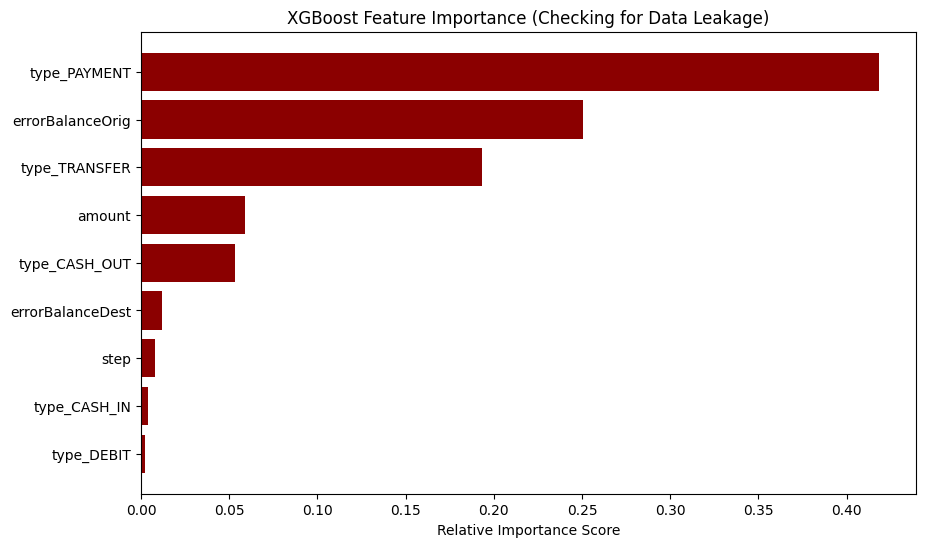

In [ ]:
#displaying feature importance in trained model
importances = baseline_model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='darkred')
plt.title('XGBoost Feature Importance (Checking for Data Leakage)')
plt.xlabel('Relative Importance Score')
plt.savefig('result.png')
plt.show()

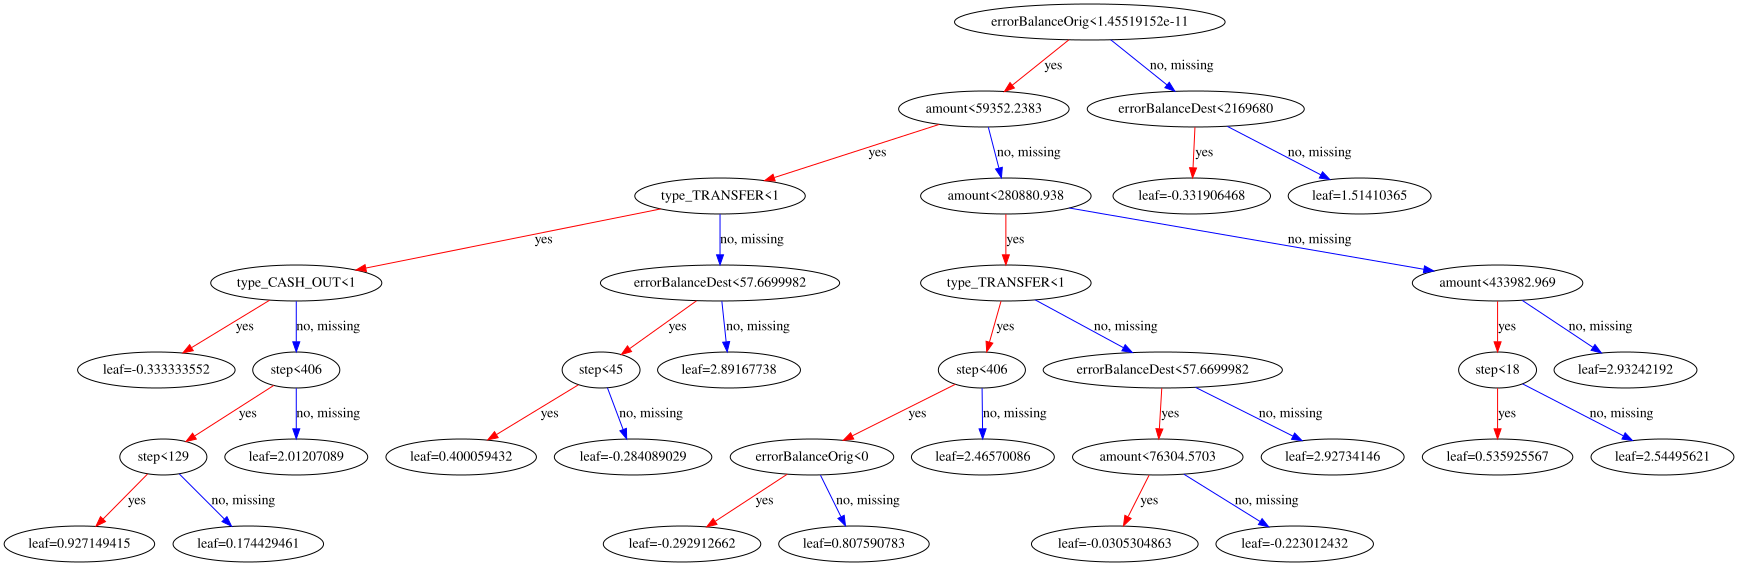

In [ ]:
#visualizing XGBoost decision tree
graph = to_graphviz(
    baseline_model,
    tree_idx=0,
    rankdir='TB'
)
display(graph)

5.2 Baseline model evaluation

In [ ]:
#making predictions and evaluating model on test data
y_test_pred = baseline_model.predict(X_test)
precision_baseline = precision_score(y_test, y_test_pred)
recall_baseline = recall_score(y_test, y_test_pred)
f1_baseline = f1_score(y_test, y_test_pred)
print("Precison:",precision_baseline)
print("Recall",recall_baseline)
print("F1-score:",f1_baseline)

Precison: 0.9579776756401839
Recall 0.9275270184361093
F1-score: 0.9425064599483204


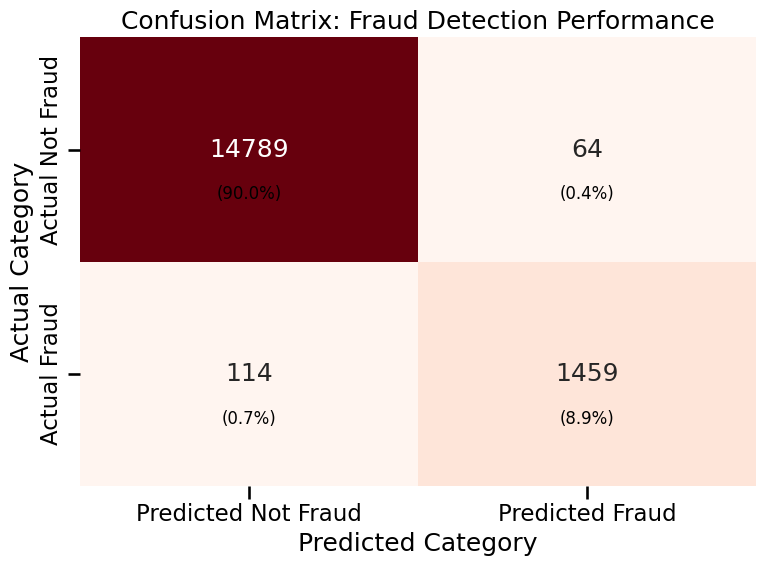

In [ ]:
#visualizing confusion matrix for baseline model
cm_baseline = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm_baseline,
                     index=['Actual Not Fraud', 'Actual Fraud'],
                     columns=['Predicted Not Fraud', 'Predicted Fraud'])
plt.figure(figsize=(8, 6))
sns.set_context('talk')
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix: Fraud Detection Performance')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
total = cm_baseline.sum()
for i in range(len(cm_baseline)):
    for j in range(len(cm_baseline)):
        plt.text(j + 0.5, i + 0.7, f"({cm_baseline[i, j]/total:.1%})",
                 ha='center', va='center', color='black', fontsize=12)
plt.tight_layout()
plt.show()

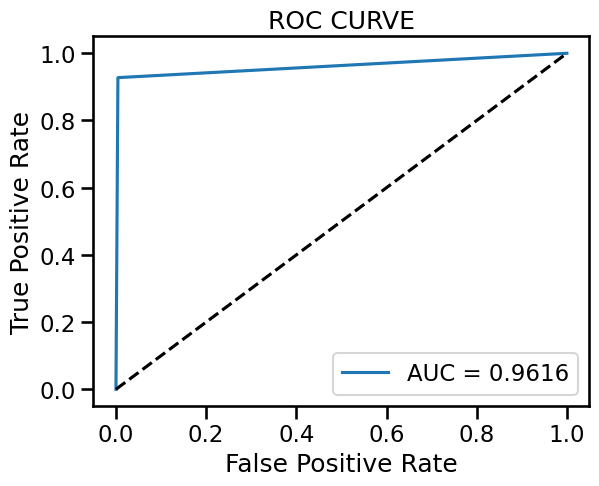

In [ ]:
#AUC-ROC score and graph for baseline model
fpr, tpr, _ = roc_curve(y_test,y_test_pred)
roc_baseline = auc(fpr, tpr)
plt.plot(fpr,tpr,label=f"AUC = {roc_baseline:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")
plt.legend()
plt.show()

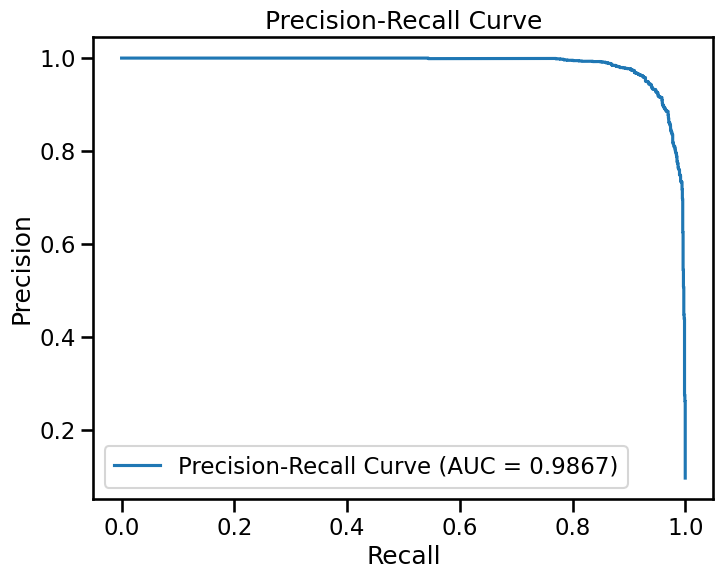

In [ ]:
#Precision-Recall curve for baseline model
y_test_prob = baseline_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)
ap_baseline = average_precision_score(y_test, y_test_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {ap_baseline:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

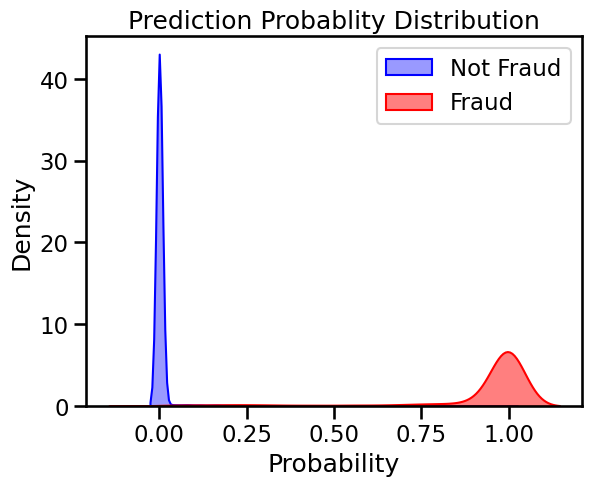

In [ ]:
#Plotting probablity distribution using kde plot for baseline model
sns.kdeplot(y_test_prob[y_test == 0], color='blue', fill=True, alpha=0.4, label='Not Fraud')
sns.kdeplot(y_test_prob[y_test == 1], color='red', fill=True, alpha=0.5, label='Fraud')
plt.xlabel('Probability')
plt.ylabel('Density')
plt.legend()
plt.title("Prediction Probablity Distribution")
plt.show()

**VI. Hyperparameter Optimization**

In [ ]:
#global dictionary for all optimizations
param_dict = {
    'n_estimators': [100,200,300],
    'learning_rate' : [0.05,0.1,0.2],
    'max_depth' : [5,7,10],
    'subsample': [0.6,0.8,1.0],
    'colsample_bytree' : [0.6,0.8,1.0],
    'scale_pos_weight' : [1,5,9]
}

In [ ]:
#defining a base xgb estimator to use across methods
xgb_model = XGBClassifier(
    objective='binary:logistic',
    random_state=42
)

6.1 Grid Search Hyperparameter Optimization

In [ ]:
#importing required libraries
from sklearn.model_selection import GridSearchCV

In [ ]:
#setting up the grid search optimization model
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_dict,
    cv=3,
    scoring='recall',
    n_jobs=1,
    verbose=2
)

In [ ]:
#grid search optimization
print("Starting Grid Search")
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()
print("Grid Search Completed")

Starting Grid Search
Fitting 3 folds for each of 729 candidates, totalling 2187 fits
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=5, n_estimators=100, scale_pos_weight=1, subsample=0.6; total time=   0.7s
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=5, n_estimators=100, scale_pos_weight=1, subsample=0.6; total time=   1.2s
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=5, n_estimators=100, scale_pos_weight=1, subsample=0.6; total time=   3.4s
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=5, n_estimators=100, scale_pos_weight=1, subsample=0.8; total time=   1.0s
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=5, n_estimators=100, scale_pos_weight=1, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=5, n_estimators=100, scale_pos_weight=1, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=5, n_estimators=100, scale_pos_weight=

In [ ]:
#displaying best parameters and extracting fully trained optimized model
print("Best Parameters from Grid Search:")
print(grid_search.best_params_)
grid_time = end_time - start_time
print("Total time taken:", grid_time, "seconds")
grid_model = grid_search.best_estimator_

Best Parameters from Grid Search:
{'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'scale_pos_weight': 9, 'subsample': 0.6}
Total time taken: 2639.763876438141 seconds


6.1.1 Grid Search Model Evaluation

In [ ]:
#making predictions and evaluating grid search optimized model on test data
y_test_pred = grid_model.predict(X_test)
precision_grid = precision_score(y_test, y_test_pred)
recall_grid = recall_score(y_test, y_test_pred)
f1_grid = f1_score(y_test, y_test_pred)
print("Precison:",precision_grid)
print("Recall",recall_grid)
print("F1-score:",f1_grid)

Precison: 0.7275685727568573
Recall 0.9949141767323586
F1-score: 0.8404940923737916


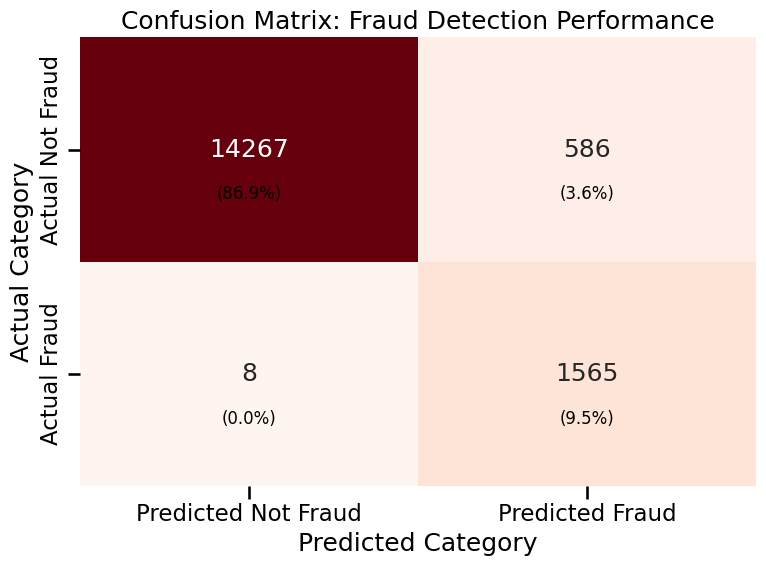

In [ ]:
#visualizing confusion matrix for grid search optimized model
cm_grid = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm_grid,
                     index=['Actual Not Fraud', 'Actual Fraud'],
                     columns=['Predicted Not Fraud', 'Predicted Fraud'])
plt.figure(figsize=(8, 6))
sns.set_context('talk')
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix: Fraud Detection Performance')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
total = cm_grid.sum()
for i in range(len(cm_grid)):
    for j in range(len(cm_grid)):
        plt.text(j + 0.5, i + 0.7, f"({cm_grid[i, j]/total:.1%})",
                 ha='center', va='center', color='black', fontsize=12)
plt.tight_layout()
plt.show()

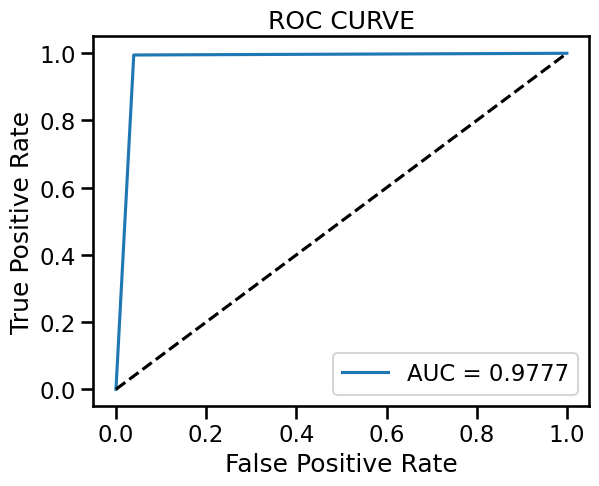

In [ ]:
#AUC-ROC score and graph for grid search optimized model
fpr, tpr, _ = roc_curve(y_test,y_test_pred)
roc_grid = auc(fpr, tpr)
plt.plot(fpr,tpr,label=f"AUC = {roc_grid:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")
plt.legend()
plt.show()

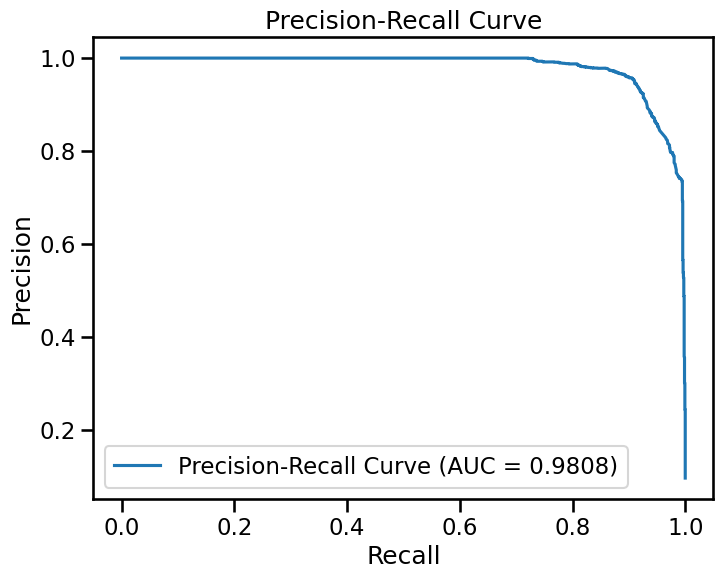

In [ ]:
#Precision-Recall curve for grid search optimized model
y_test_prob = grid_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)
ap_grid = average_precision_score(y_test, y_test_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {ap_grid:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

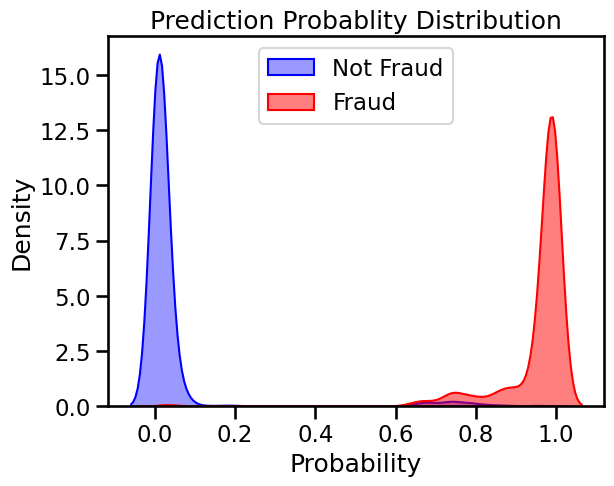

In [ ]:
#plotting probablity distribution using kde plot for grid search optimized model
sns.kdeplot(y_test_prob[y_test == 0], color='blue', fill=True, alpha=0.4, label='Not Fraud')
sns.kdeplot(y_test_prob[y_test == 1], color='red', fill=True, alpha=0.5, label='Fraud')
plt.xlabel('Probability')
plt.ylabel('Density')
plt.legend()
plt.title("Prediction Probablity Distribution")
plt.show()

6.2 Random Search Hyperparameter Optimization

In [ ]:
#importing required libraries
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
#setting up random search optimization model
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions = param_dict,
    n_iter = 100,
    scoring = 'recall',
    cv = 3,
    random_state=42,
    verbose = 1,
    n_jobs=1
)

In [ ]:
#random search optimization
print("Starting Random Search")
start_random = time.time()
random_search.fit(X_train,y_train)
end_random=time.time()
print("Random Search Completed")

Starting Random Search
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Random Search Completed


In [ ]:
#displaying best parameters and extracting fully trained optimized model
print("Best parametres from Random Search: ")
print(random_search.best_params_)
random_time = end_random - start_random
print("Total time taken:", random_time, "seconds")
random_model = random_search.best_estimator_

Best parametres from Random Search: 
{'subsample': 0.6, 'scale_pos_weight': 9, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Total time taken: 368.23757219314575 seconds


6.2.1 Random Search Model Evaluation

In [ ]:
#making predictions and evaluating random search optimized model on test data
y_test_pred = random_model.predict(X_test)
precision_random = precision_score(y_test, y_test_pred)
recall_random = recall_score(y_test, y_test_pred)
f1_random = f1_score(y_test, y_test_pred)
print("Precison:",precision_random)
print("Recall",recall_random)
print("F1-score:",f1_random)

Precison: 0.7401798390913393
Recall 0.9942784488239034
F1-score: 0.8486163863266414


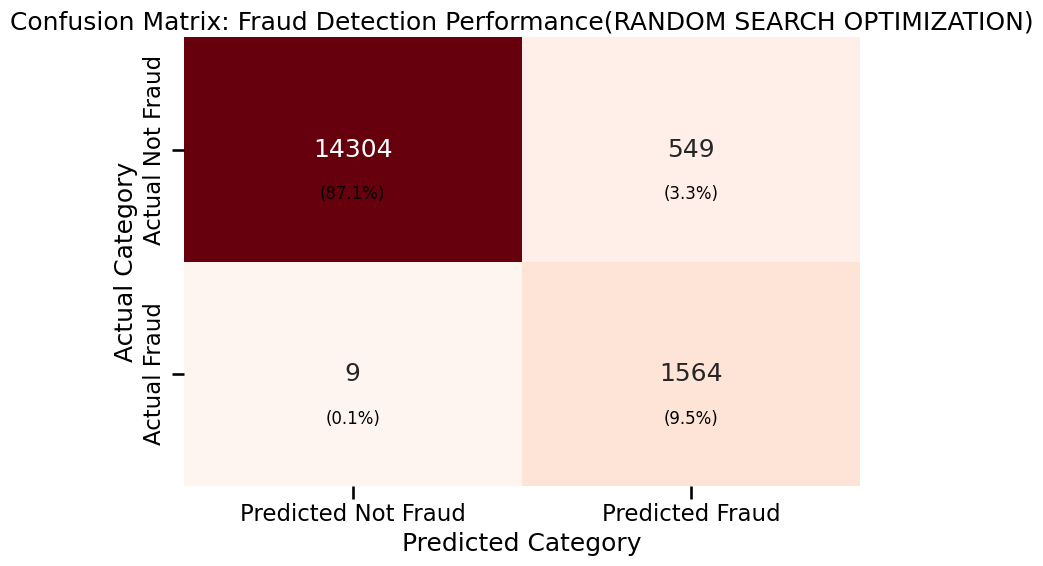

In [ ]:
#visualizing confusion matrix for random search model
cm_random = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm_random,
                     index=['Actual Not Fraud', 'Actual Fraud'],
                     columns=['Predicted Not Fraud', 'Predicted Fraud'])
plt.figure(figsize=(8, 6))
sns.set_context('talk')
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix: Fraud Detection Performance(RANDOM SEARCH OPTIMIZATION)')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
total = cm_random.sum()
for i in range(len(cm_random)):
    for j in range(len(cm_random)):
        plt.text(j + 0.5, i + 0.7, f"({cm_random[i, j]/total:.1%})",
                 ha='center', va='center', color='black', fontsize=12)
plt.tight_layout()
plt.show()

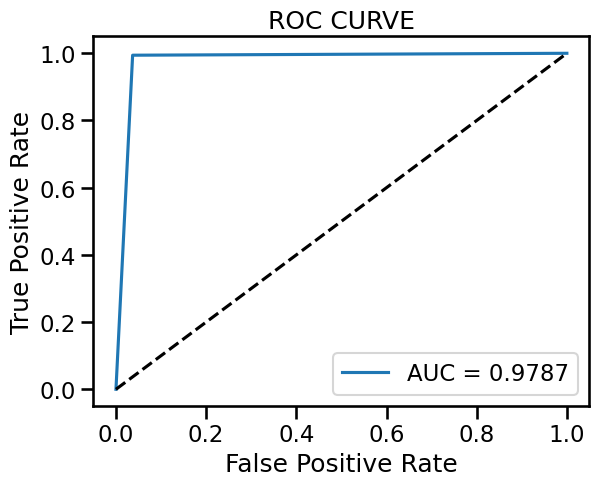

In [ ]:
#AUC-ROC score and graph for random search optimized model
fpr, tpr, _ = roc_curve(y_test,y_test_pred)
roc_random = auc(fpr, tpr)
plt.plot(fpr,tpr,label=f"AUC = {roc_random:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")
plt.legend()
plt.show()


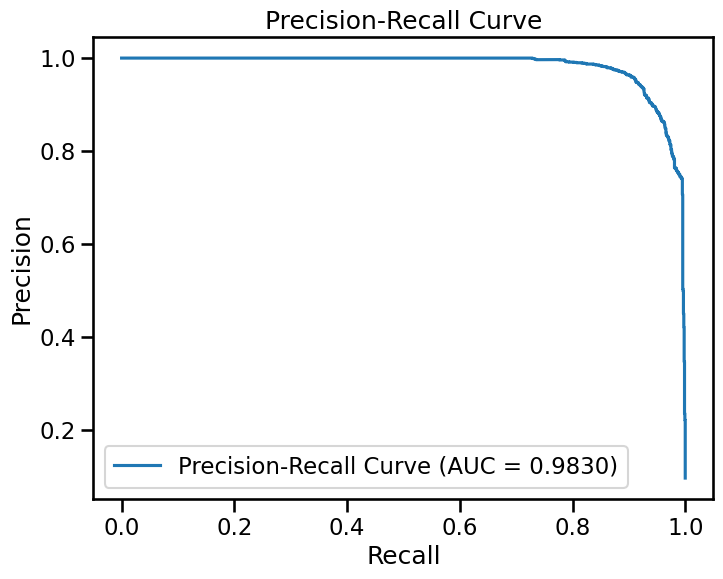

In [ ]:
#Precision recall curve for random search optimized model
y_test_prob = random_model.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test,y_test_prob)
ap_random = average_precision_score(y_test,y_test_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {ap_random:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

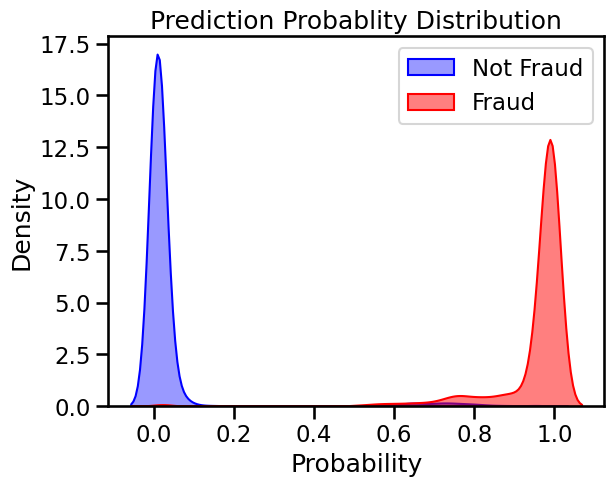

In [ ]:
#Plotting probablity distribution using kde plot for random search optimized model
sns.kdeplot(y_test_prob[y_test == 0], color='blue', fill=True, alpha=0.4, label='Not Fraud')
sns.kdeplot(y_test_prob[y_test == 1], color='red', fill=True, alpha=0.5, label='Fraud')
plt.xlabel('Probability')
plt.ylabel('Density')
plt.legend()
plt.title("Prediction Probablity Distribution")
plt.show()

6.3 Bayesian Hyperparameter Optimization

In [ ]:
#installing optuna library
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.7 MB/s eta 0:00:00


In [ ]:
#importing required libraries
import optuna
from sklearn.model_selection import cross_val_score
from optuna.samplers import TPESampler

In [ ]:
#defining the objective function
def objective(trial):
  param = {'learning_rate': trial.suggest_categorical('learning_rate', [0.05, 0.1, 0.2]),
        'n_estimators': trial.suggest_categorical('n_estimators', [100, 200, 300]),
        'max_depth': trial.suggest_categorical('max_depth', [5, 7, 10]),
        'subsample': trial.suggest_categorical('subsample', [0.6, 0.8, 1.0]),
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.6, 0.8, 1.0]),
        'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', [1, 5, 9]),

        # The unified baseline settings
        'objective': 'binary:logistic',
        'random_state': 42,
        'n_jobs': 1}
  model = XGBClassifier(**param)
  score = cross_val_score(model, X_train, y_train, cv=3, scoring='recall').mean()
  return score

In [ ]:
#creating a new study object
seed_sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', study_name = "XGBoost fraud detection", sampler=seed_sampler )

[I 2026-05-28 10:19:49,870] A new study created in memory with name: XGBoost fraud detection


In [ ]:
#bayesian optimization using optuna
print("Starting Bayesian Optimization")
start_time = time.time()
study.optimize(objective, n_trials=100)
end_time = time.time()
print("Bayesian Optimization Completed")

Starting Bayesian Optimization


[I 2026-05-28 10:19:54,538] Trial 0 finished with value: 0.9896087053956849 and parameters: {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 7, 'subsample': 1.0, 'colsample_bytree': 0.6, 'scale_pos_weight': 9}. Best is trial 0 with value: 0.9896087053956849.
[I 2026-05-28 10:20:02,783] Trial 1 finished with value: 0.9481932676433757 and parameters: {'learning_rate': 0.2, 'n_estimators': 300, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.6, 'scale_pos_weight': 5}. Best is trial 0 with value: 0.9896087053956849.
[I 2026-05-28 10:20:08,778] Trial 2 finished with value: 0.9414160908692484 and parameters: {'learning_rate': 0.2, 'n_estimators': 300, 'max_depth': 7, 'subsample': 0.6, 'colsample_bytree': 1.0, 'scale_pos_weight': 5}. Best is trial 0 with value: 0.9896087053956849.
[I 2026-05-28 10:20:13,004] Trial 3 finished with value: 0.9305728529494965 and parameters: {'learning_rate': 0.1, 'n_estimators': 300, 'max_depth': 10, 'subsample': 1.0, 'colsample_bytree': 0.8, 'sc

Bayesian Optimization Completed


In [ ]:
#displaying best parameters and time taken for optmization
print("Best Parameters from Bayesian Optimization:")
print(study.best_params)
Bayesian_time = end_time - start_time
print("Total time taken:", Bayesian_time, "seconds")

Best Parameters from Bayesian Optimization:
{'learning_rate': 0.05, 'n_estimators': 100, 'max_depth': 5, 'subsample': 0.6, 'colsample_bytree': 0.6, 'scale_pos_weight': 9}
Total time taken: 226.67525720596313 seconds


In [ ]:
#training XGBoost model with bayesian optimized parameters
bayesian_model = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    **study.best_params
)
bayesian_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, ...)

6.3.1 Bayesian Model Evaluation

In [ ]:
#making predictions and evaluating bayesian optmized model on test data
y_test_pred = bayesian_model.predict(X_test)
precision_bayesian = precision_score(y_test, y_test_pred)
recall_bayesian = recall_score(y_test, y_test_pred)
f1_bayesian = f1_score(y_test, y_test_pred)
print("Precison:",precision_bayesian)
print("Recall",recall_bayesian)
print("F1-score:",f1_bayesian)

Precison: 0.7275685727568573
Recall 0.9949141767323586
F1-score: 0.8404940923737916


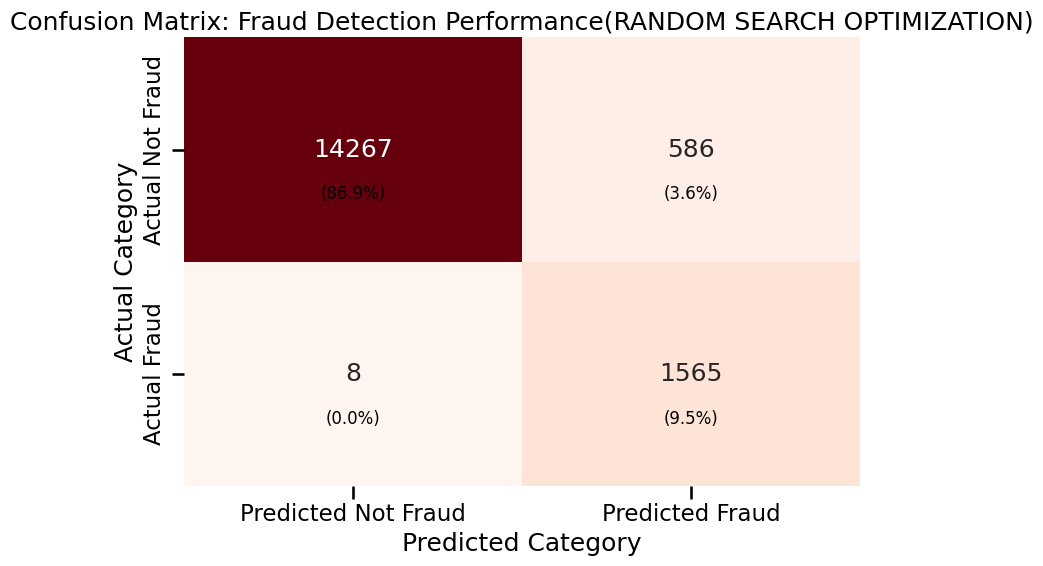

In [ ]:
#visualizing confusion matrix for bayesian optimization model
cm_bayesian = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm_bayesian,
                     index=['Actual Not Fraud', 'Actual Fraud'],
                     columns=['Predicted Not Fraud', 'Predicted Fraud'])
plt.figure(figsize=(8, 6))
sns.set_context('talk')
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix: Fraud Detection Performance(RANDOM SEARCH OPTIMIZATION)')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
total = cm_bayesian.sum()
for i in range(len(cm_bayesian)):
    for j in range(len(cm_bayesian)):
        plt.text(j + 0.5, i + 0.7, f"({cm_bayesian[i, j]/total:.1%})",
                 ha='center', va='center', color='black', fontsize=12)
plt.tight_layout()
plt.show()

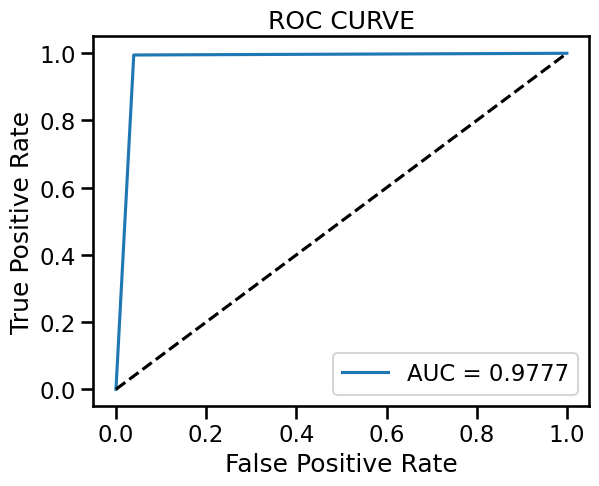

In [ ]:
#AUC-ROC score and graph for bayesian optimized model
fpr, tpr, _ = roc_curve(y_test,y_test_pred)
roc_bayesian = auc(fpr, tpr)
plt.plot(fpr,tpr,label=f"AUC = {roc_bayesian:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")
plt.legend()
plt.show()


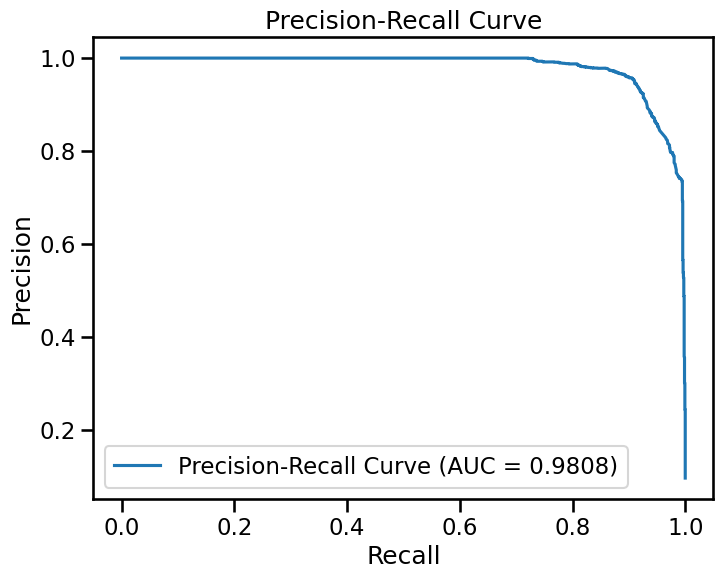

In [ ]:
#Precision-Recall curve for bayesian optimized model
y_test_prob = bayesian_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)
ap_bayesian = average_precision_score(y_test, y_test_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {ap_bayesian:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

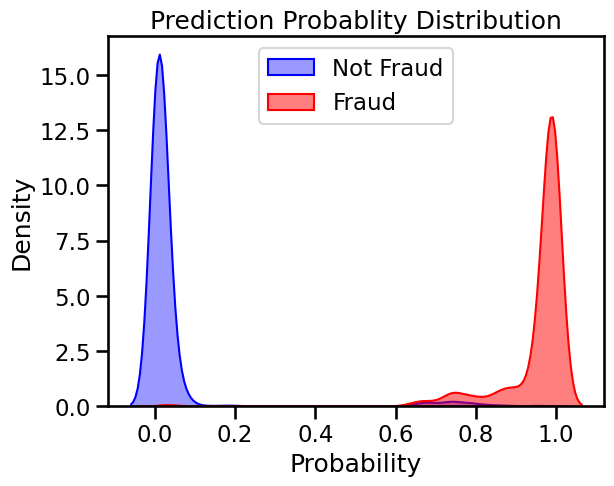

In [ ]:
#Plotting probablity distribution using kde plot for random search optimized model
sns.kdeplot(y_test_prob[y_test == 0], color='blue', fill=True, alpha=0.4, label='Not Fraud')
sns.kdeplot(y_test_prob[y_test == 1], color='red', fill=True, alpha=0.5, label='Fraud')
plt.xlabel('Probability')
plt.ylabel('Density')
plt.legend()
plt.title("Prediction Probablity Distribution")
plt.show()

**VII. Comparative Study**

In [ ]:
#importing required libraries
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#displaying best parameters for each model
best_params = dict()
for key in param_dict.keys():
  best_params[key] = [grid_search.best_params_[key],random_search.best_params_[key],study.best_params[key]]
best_params_df = pd.DataFrame(best_params, index=['Grid Search','Random Search','Bayesian'])
best_params_df

,n_estimators,learning_rate,max_depth,subsample,colsample_bytree,scale_pos_weight
Grid Search,100,0.05,5,0.6,0.6,9
Random Search,100,0.05,7,0.6,0.6,9
Bayesian,100,0.05,5,0.6,0.6,9


In [ ]:
#combining results of optimized models into a dataframe
results = {
    'Precision': [precision_baseline,precision_grid, precision_random, precision_bayesian],
    'Recall': [recall_baseline,recall_grid, recall_random, recall_bayesian],
    'F1 Score': [f1_baseline,f1_grid, f1_random, f1_bayesian],
    'Time Taken': [baseline_time,grid_time, random_time, Bayesian_time],
    'ROC_AUC': [roc_baseline,roc_grid, roc_random, roc_bayesian],
    'PR_AUC':[ap_baseline,ap_grid,ap_random,ap_bayesian]
}

comparison_df = pd.DataFrame(results, index=['Baseline Model','Grid Search', 'Random Search', 'Bayesian'])
comparison_df

,Precision,Recall,F1 Score,Time Taken,ROC_AUC,PR_AUC
Baseline Model,0.957978,0.927527,0.942506,0.545343,0.961609,0.986742
Grid Search,0.727569,0.994914,0.840494,2639.763876,0.977730,0.980835
Random Search,0.740180,0.994278,0.848616,368.237572,0.978658,0.982968
Bayesian,0.727569,0.994914,0.840494,226.675257,0.977730,0.980835


In [ ]:
#tabulating the results of confusion matrix
cm_combined = {
    'True Negative': [cm_baseline[0][0], cm_grid[0][0], cm_random[0][0], cm_bayesian[0][0]],
    'False Positive': [cm_baseline[0][1], cm_grid[0][1], cm_random[0][1], cm_bayesian[0][1]],
    'False Negative': [cm_baseline[1][0], cm_grid[1][0], cm_random[1][0], cm_bayesian[1][0]],
    'True Positive': [cm_baseline[1][1], cm_grid[1][1], cm_random[1][1], cm_bayesian[1][1]]
}
cm_combined_df = pd.DataFrame(cm_combined, index=['Baseline Model','Grid Search', 'Random Search', 'Bayesian'])
cm_combined_df

,True Negative,False Positive,False Negative,True Positive
Baseline Model,14789,64,114,1459
Grid Search,14267,586,8,1565
Random Search,14304,549,9,1564
Bayesian,14267,586,8,1565


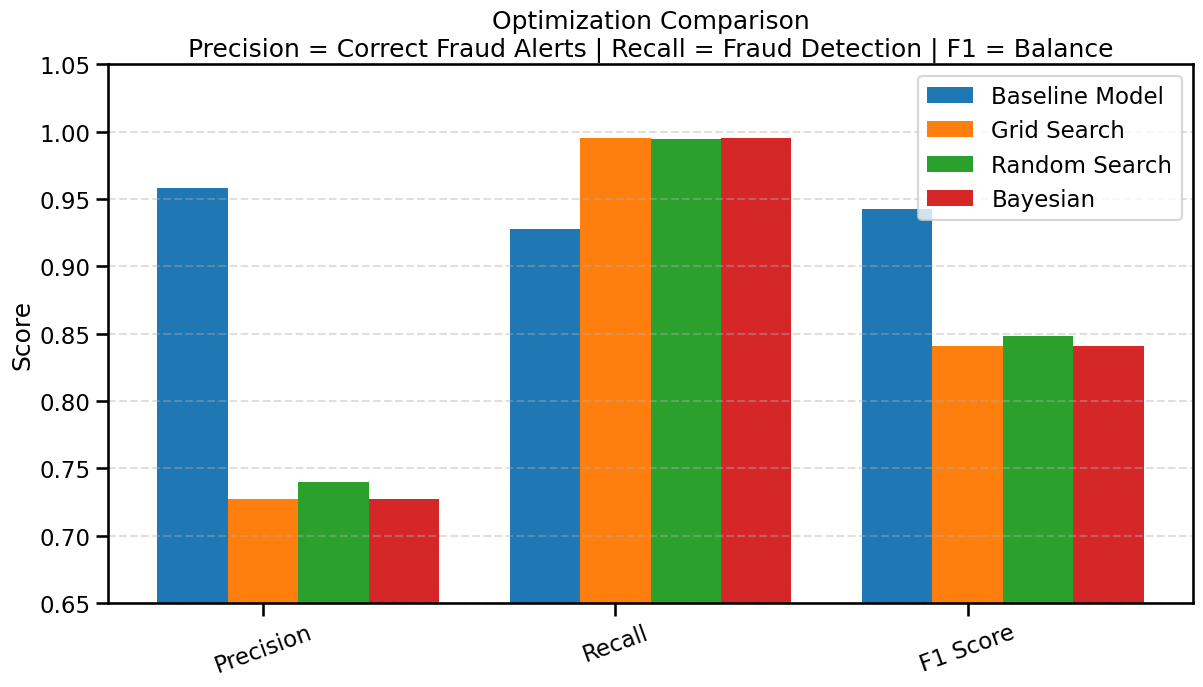

In [ ]:
#master comparision graph (Precision / Recall / F1 Score)

metrics = ["Precision", "Recall", "F1 Score"]

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(14,7))

for i, model in enumerate(comparison_df.index):
    plt.bar(x + i*width, comparison_df.loc[model, metrics], width=width, label=model)

plt.xticks(x + width, metrics, rotation=20)
plt.ylim(0.65,1.05)

plt.title("Optimization Comparison\nPrecision = Correct Fraud Alerts | Recall = Fraud Detection | F1 = Balance")
plt.ylabel("Score")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

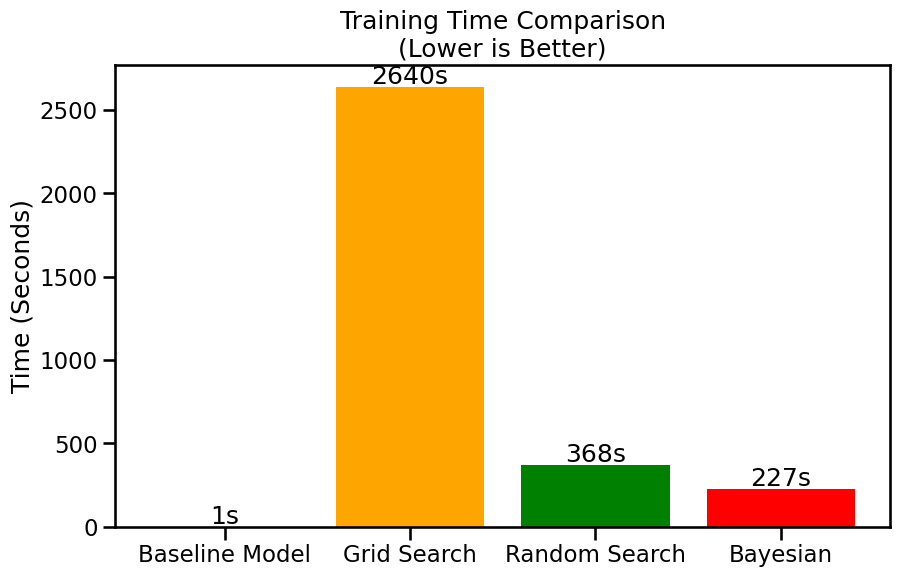

In [ ]:
#Hyperparameter Optimization time Comparison

plt.figure(figsize=(10,6))

bars = plt.bar(comparison_df.index, comparison_df["Time Taken"], color=['blue','orange','green','red'])

plt.title("Training Time Comparison\n(Lower is Better)")
plt.ylabel("Time (Seconds)")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+20, f"{y:.0f}s", ha='center')

plt.show()

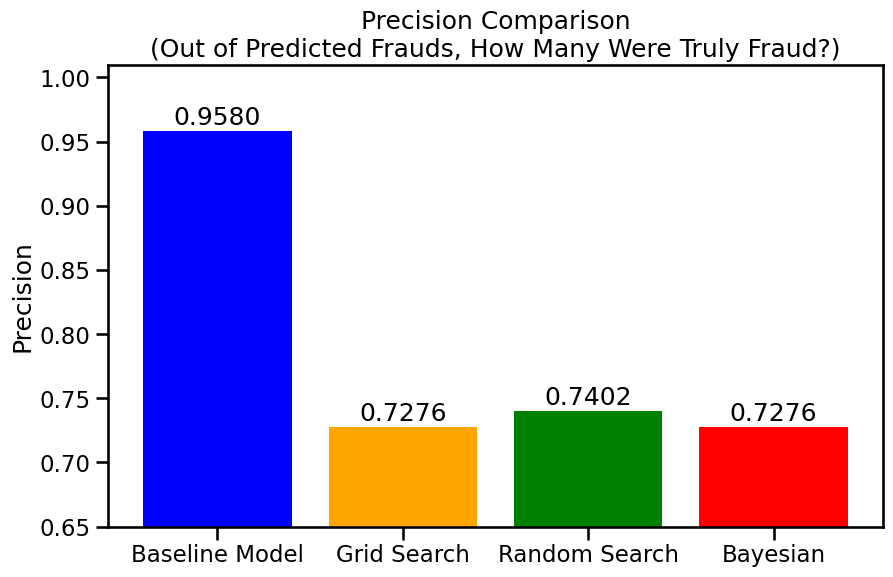

In [ ]:
#precision comparision

plt.figure(figsize=(10,6))

bars = plt.bar(comparison_df.index, comparison_df["Precision"], color=['blue','orange','green','red'])

plt.title("Precision Comparison\n(Out of Predicted Frauds, How Many Were Truly Fraud?)")
plt.ylabel("Precision")
plt.ylim(0.65,1.01)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+0.005, f"{y:.4f}", ha='center')

plt.show()

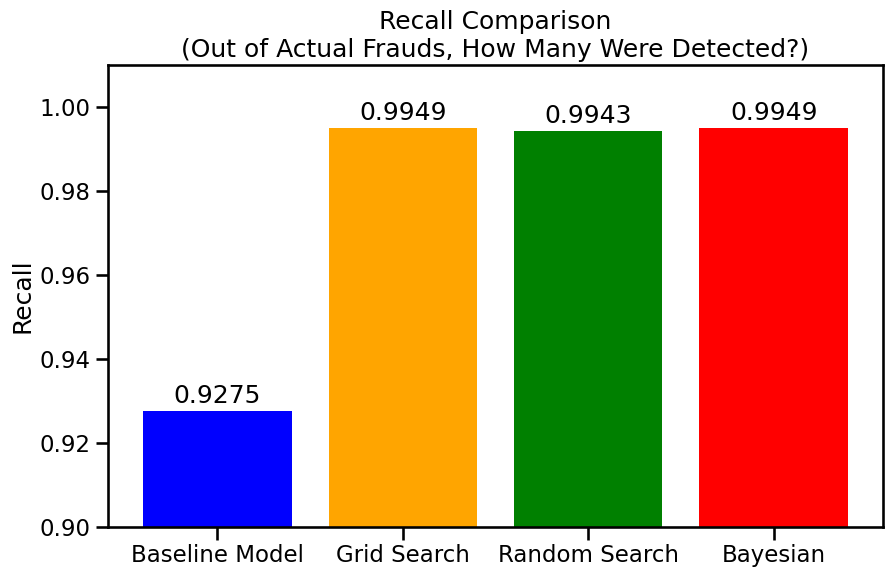

In [ ]:
#recall comparison

plt.figure(figsize=(10,6))

bars = plt.bar(comparison_df.index, comparison_df["Recall"], color=['blue','orange','green','red'])

plt.title("Recall Comparison\n(Out of Actual Frauds, How Many Were Detected?)")
plt.ylabel("Recall")
plt.ylim(0.90,1.01)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+0.002, f"{y:.4f}", ha='center')

plt.show()

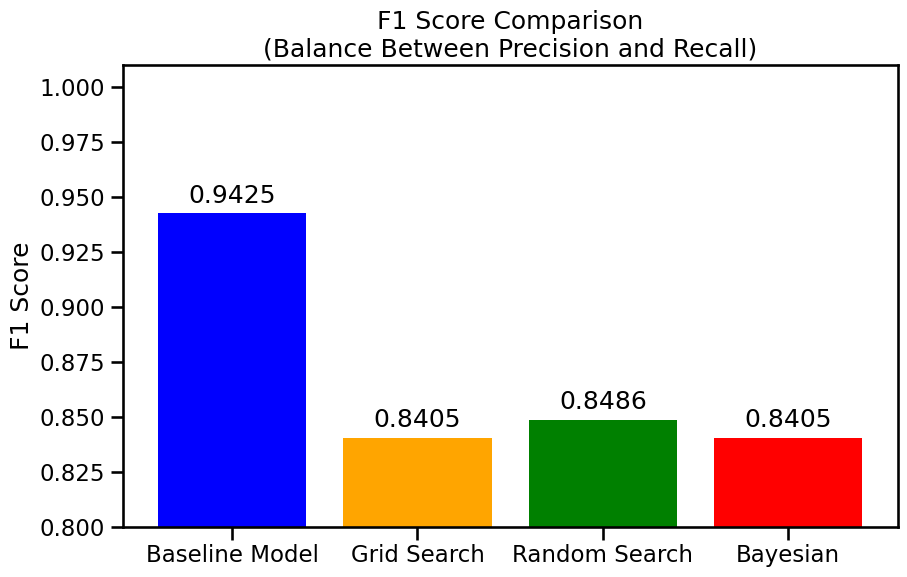

In [ ]:
#f1 score comparision

plt.figure(figsize=(10,6))

bars = plt.bar(comparison_df.index, comparison_df["F1 Score"], color=['blue','orange','green','red'])

plt.title("F1 Score Comparison\n(Balance Between Precision and Recall)")
plt.ylabel("F1 Score")
plt.ylim(0.80,1.01)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+0.005, f"{y:.4f}", ha='center')

plt.show()

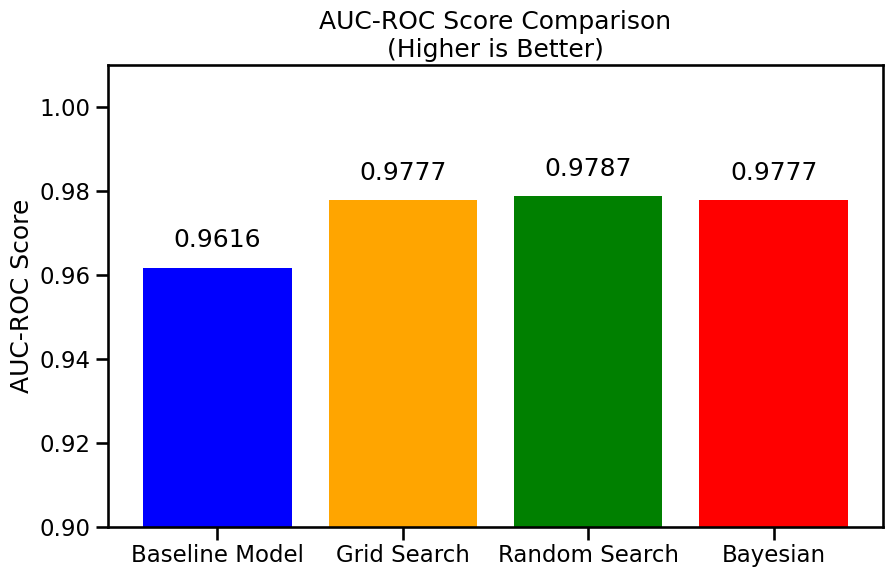

In [ ]:
#AUC-ROC score comparision
plt.figure(figsize=(10,6))

bars = plt.bar(comparison_df.index, comparison_df["ROC_AUC"], color=['blue','orange','green','red'])

plt.title("AUC-ROC Score Comparison\n(Higher is Better)")
plt.ylabel("AUC-ROC Score")
plt.ylim(0.90,1.01)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+0.005, f"{y:.4f}", ha='center')

plt.show()

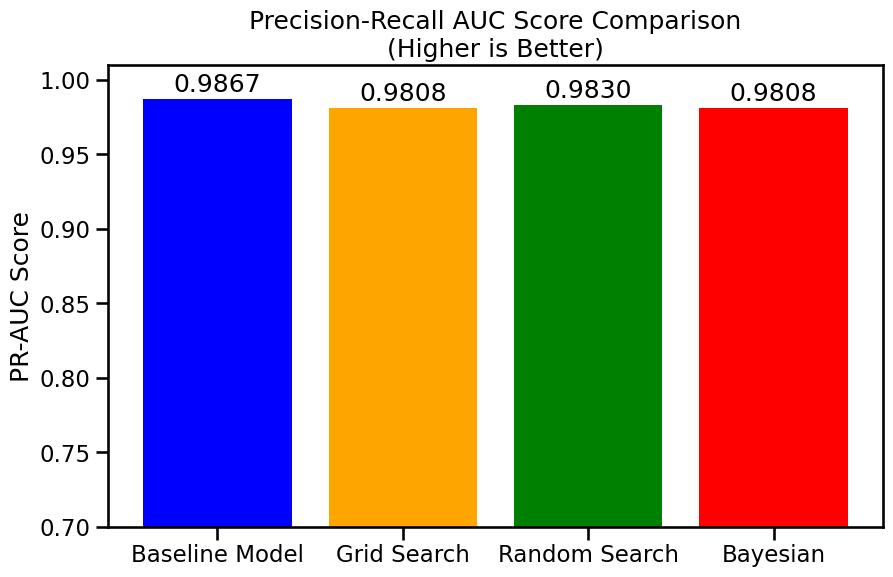

In [ ]:
#PR-AUC score comparision
plt.figure(figsize=(10,6))

bars = plt.bar(comparison_df.index, comparison_df["PR_AUC"], color=['blue','orange','green','red'])

plt.title("Precision-Recall AUC Score Comparison\n(Higher is Better)")
plt.ylabel("PR-AUC Score")
plt.ylim(0.70,1.01)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+0.005, f"{y:.4f}", ha='center')

plt.show()

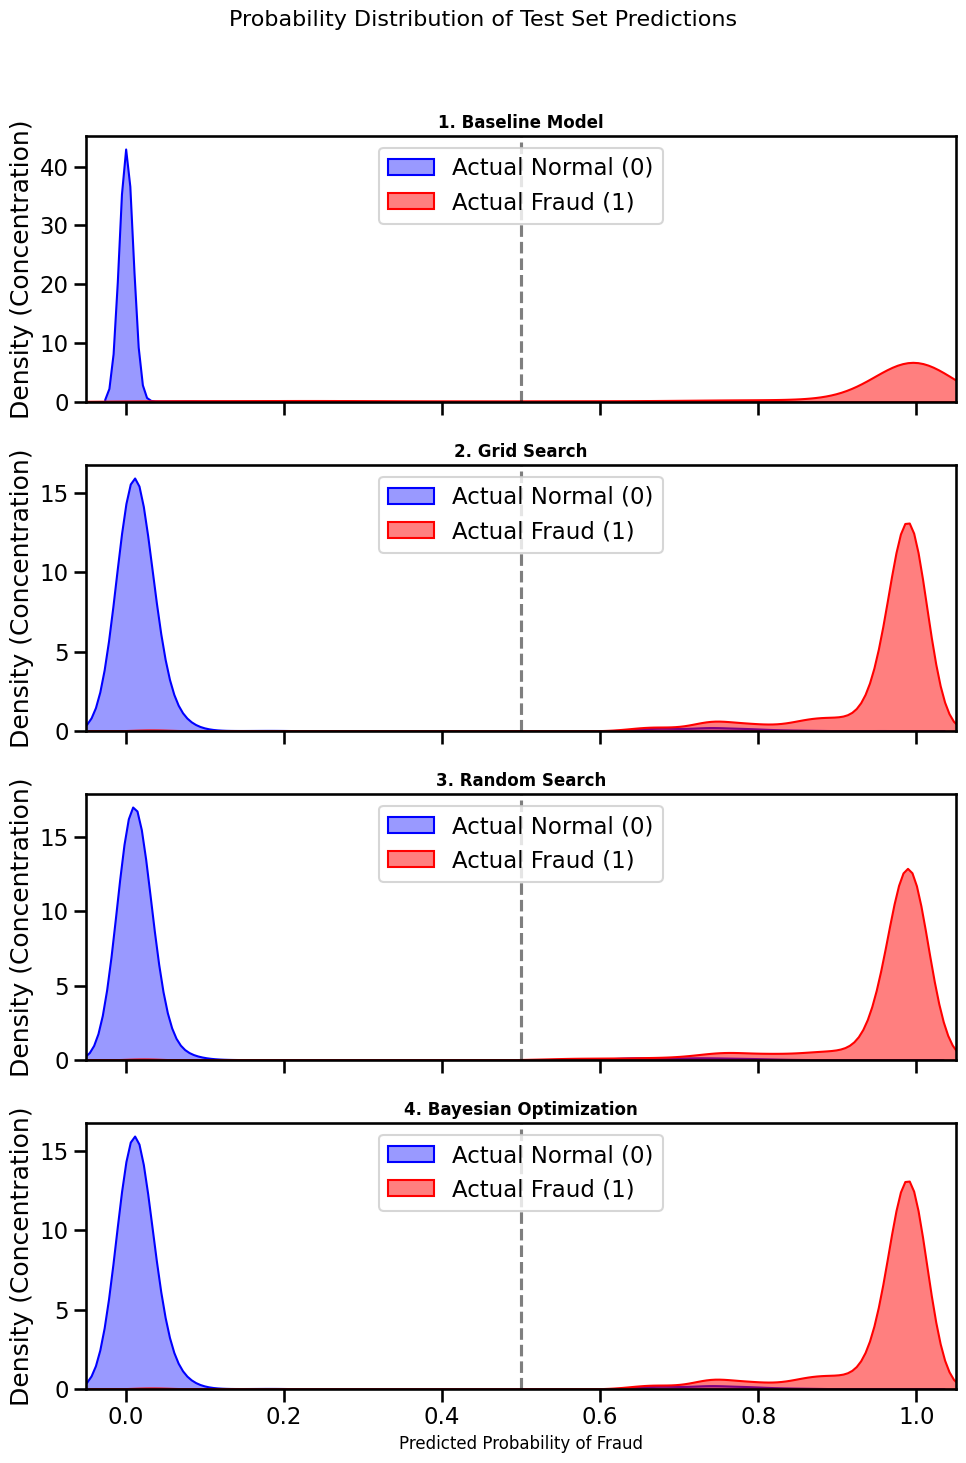

In [ ]:
#plotting each models probablity distribution vertically for comparision
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]
y_prob_grid = grid_model.predict_proba(X_test)[:, 1]
y_prob_random = random_model.predict_proba(X_test)[:, 1]
y_prob_bayesian = bayesian_model.predict_proba(X_test)[:, 1]

models_dict = {
    '1. Baseline Model': y_prob_baseline,
    '2. Grid Search': y_prob_grid,
    '3. Random Search': y_prob_random,
    '4. Bayesian Optimization': y_prob_bayesian
}

fig, axes = plt.subplots(4, 1, figsize=(10, 15), sharex=True)
fig.suptitle('Probability Distribution of Test Set Predictions', fontsize=16, y=0.98)

for ax, (model_name, y_prob) in zip(axes, models_dict.items()):
    sns.kdeplot(y_prob[y_test == 0], ax=ax, color='blue', fill=True, alpha=0.4, label='Actual Normal (0)')
    sns.kdeplot(y_prob[y_test == 1], ax=ax, color='red', fill=True, alpha=0.5, label='Actual Fraud (1)')
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Density (Concentration)')
    ax.legend(loc='upper center')
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='50% Threshold')

plt.xlabel('Predicted Probability of Fraud', fontsize=12)
plt.xlim(-0.05, 1.05)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**VIII. Displaying characteristics of best model (Bayesian optimzed)**

In [ ]:
#importing required libraries
import optuna.visualization.matplotlib as vis

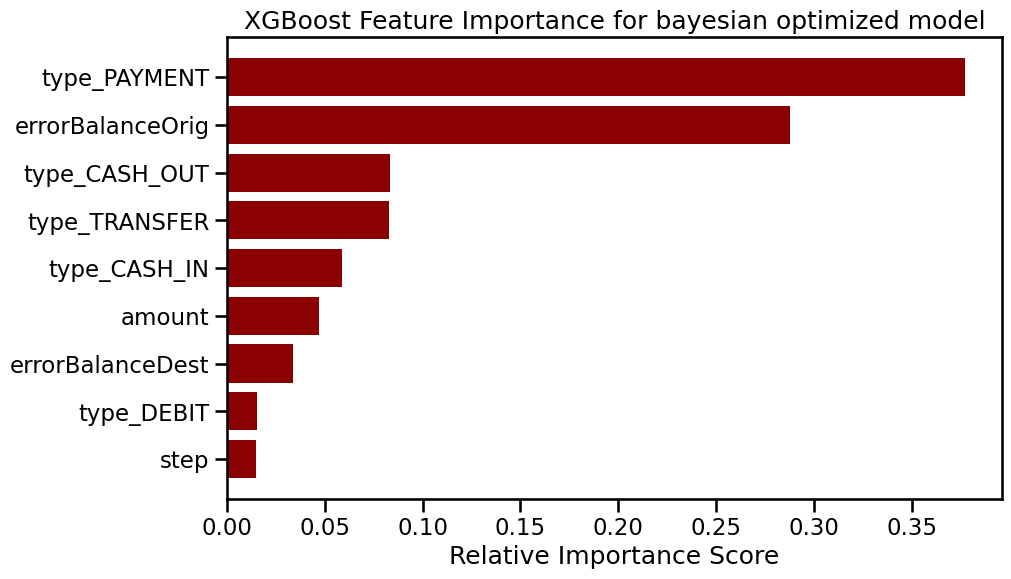

In [ ]:
#displaying feature importance in bayesian model
importances = bayesian_model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='darkred')
plt.title('XGBoost Feature Importance for bayesian optimized model')
plt.xlabel('Relative Importance Score')
plt.savefig('result.png')
plt.show()

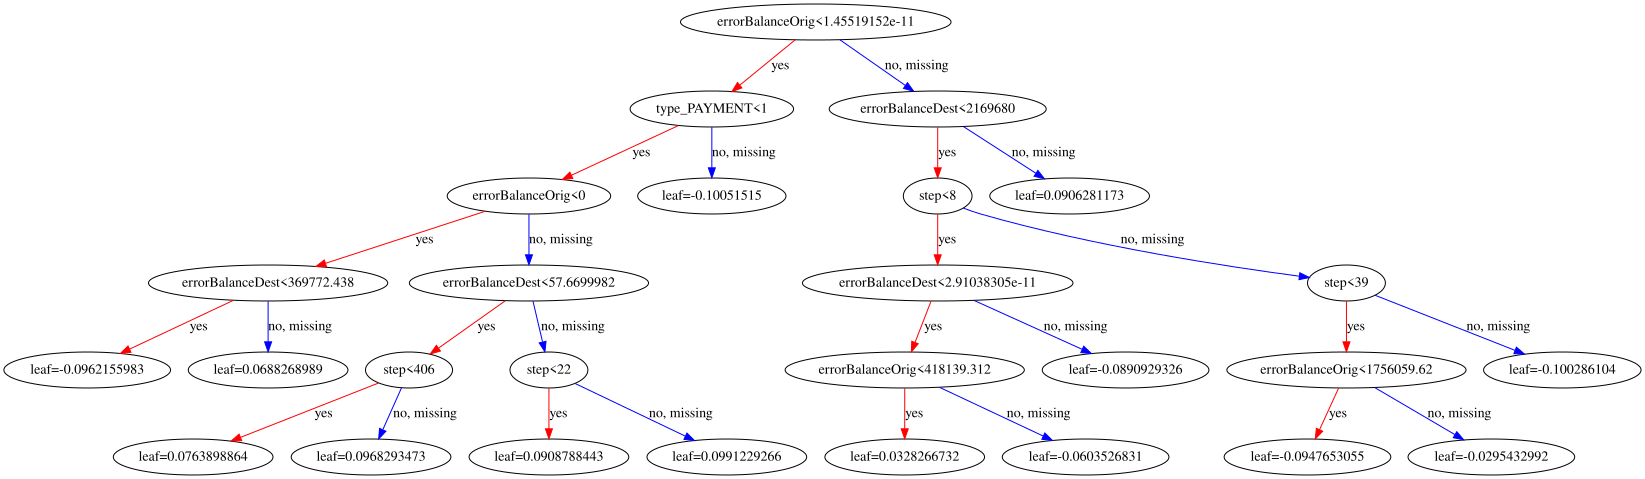

In [ ]:
#tree of bayesian model
graph = to_graphviz(bayesian_model, tree_idx=0, rankdir='TB')
display(graph)

/tmp/ipykernel_4322/2650392660.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(study)


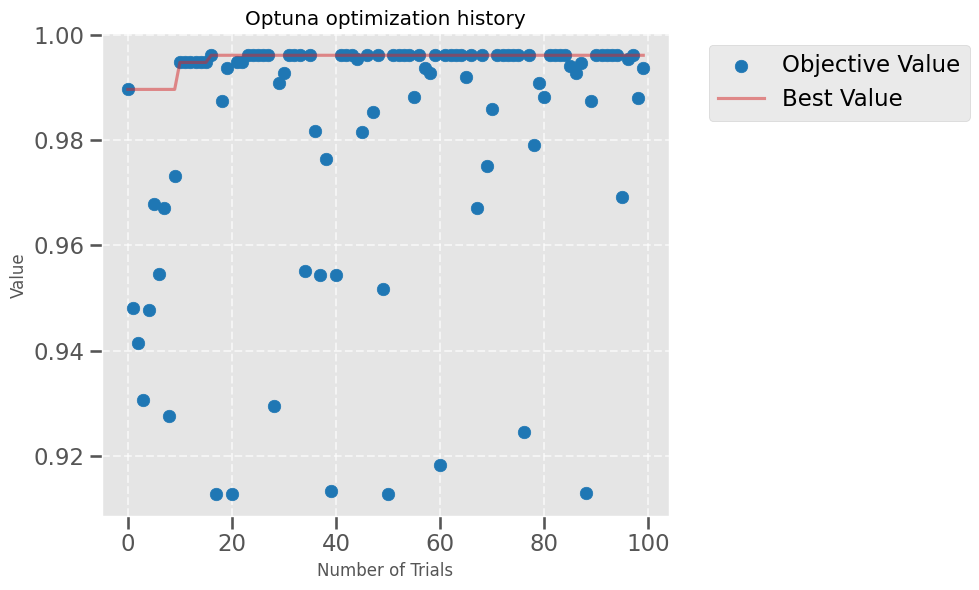

In [ ]:
#optuna optimization history plot
ax = vis.plot_optimization_history(study)
fig=ax.figure
fig.set_size_inches(10, 6)
plt.title('Optuna optimization history')
ax.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('Number of Trials')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

/tmp/ipykernel_16402/906105689.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax=vis.plot_param_importances(study)


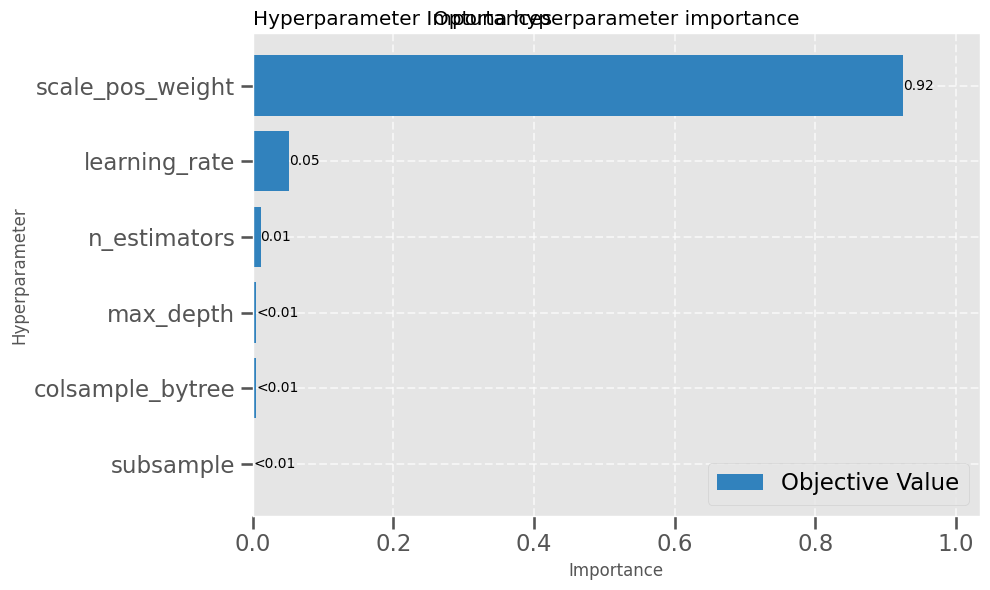

In [ ]:
#optuna hyperparameter importance plot
ax=vis.plot_param_importances(study)
fig=ax.figure
fig.set_size_inches(10, 6)
plt.title('Optuna hyperparameter importance')
print()
ax.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('Importance')
plt.ylabel('Hyperparameter')
plt.tight_layout()
plt.show()